In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
url="https://raw.githubusercontent.com/nikitaguptasrivastava-cell/Information-Assurance/refs/heads/main/Credit_card_fraud_detection_dataset_csv.csv"
df_main=pd.read_csv(url)
df_main.head(20)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
1,T2,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
2,T3,2095,2372.04,ATM Withdrawal,15.0,Desktop,Boston,3,96,14,Credit Card,0
3,T4,2238,2733.84,Bill Payment,20.0,Mobile,San Francisco,2,68,1,Credit Card,0
4,T5,3433,4519.04,Bill Payment,13.0,Tablet,Boston,0,81,10,Credit Card,1
5,T6,3324,428.39,POS Payment,20.0,Desktop,New York,0,85,10,Credit Card,0
6,T7,3904,821.79,ATM Withdrawal,7.0,Mobile,San Francisco,2,116,10,Credit Card,0
7,T8,3047,4413.05,Bank Transfer,21.0,Desktop,Boston,4,46,11,Credit Card,1
8,T9,1975,4972.42,Online Purchase,13.0,Tablet,Houston,1,93,14,Credit Card,0
9,T10,2528,2382.83,POS Payment,NaN,Unknown Device,New York,0,27,14,Credit Card,0


https://www.kaggle.com/datasets/ranjitmandal/fraud-detection-dataset-csv/data?select=Fraud+Detection+Dataset.csv

In [6]:
df_main.shape

(11646, 12)

In [7]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11646 entries, 0 to 11645
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    11646 non-null  object 
 1   User_ID                           11646 non-null  int64  
 2   Transaction_Amount                11087 non-null  float64
 3   Transaction_Type                  11646 non-null  object 
 4   Time_of_Transaction               11014 non-null  float64
 5   Device_Used                       11082 non-null  object 
 6   Location                          11054 non-null  object 
 7   Previous_Fraudulent_Transactions  11646 non-null  int64  
 8   Account_Age                       11646 non-null  int64  
 9   Number_of_Transactions_Last_24H   11646 non-null  int64  
 10  Payment_Method                    11646 non-null  object 
 11  Fraudulent                        11646 non-null  int64  
dtypes: f

In [8]:
df_main.describe() #obeserved that dataset has missing values

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,11646.000000,11087.000000,11014.000000,11646.000000,11646.000000,11646.000000,11646.000000
mean,3000.026704,3027.154358,11.497639,1.999485,60.156019,7.545767,0.049287
std,1151.171664,5217.557303,6.876962,1.417549,34.275107,4.024411,0.216477
min,1001.000000,5.470000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2000.000000,1269.365000,6.000000,1.000000,30.250000,4.000000,0.000000
50%,2992.000000,2518.500000,12.000000,2.000000,60.000000,8.000000,0.000000
75%,4005.000000,3798.020000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [9]:
# checking the columns for null values
df_main.isnull().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,559
Transaction_Type,0
Time_of_Transaction,632
Device_Used,564
Location,592
Previous_Fraudulent_Transactions,0
Account_Age,0
Number_of_Transactions_Last_24H,0


In [10]:
#finding the null percentages across columns
round(df_main.isnull().sum()/len(df_main.index),4)*100

,0
Transaction_ID,0.00
User_ID,0.00
Transaction_Amount,4.80
Transaction_Type,0.00
Time_of_Transaction,5.43
Device_Used,4.84
Location,5.08
Previous_Fraudulent_Transactions,0.00
Account_Age,0.00
Number_of_Transactions_Last_24H,0.00


In [11]:
round(df_main["Location"].value_counts(normalize=True),6)*100


,proportion
Location,
Seattle,12.9546
Chicago,12.8641
Boston,12.5023
San Francisco,12.4932
Miami,12.3847
New York,12.3575
Houston,12.2399
Los Angeles,12.2037


In [12]:
# Imputing the missing data in the 'City' column with 'Seattle'as it has the highest proportion
df_main["Location"]=df_main["Location"].replace(np.nan,'Seattle')

In [13]:
# Finding the null percentages across columns
round(df_main.isnull().sum()/len(df_main.index),4)*100

,0
Transaction_ID,0.00
User_ID,0.00
Transaction_Amount,4.80
Transaction_Type,0.00
Time_of_Transaction,5.43
Device_Used,4.84
Location,0.00
Previous_Fraudulent_Transactions,0.00
Account_Age,0.00
Number_of_Transactions_Last_24H,0.00


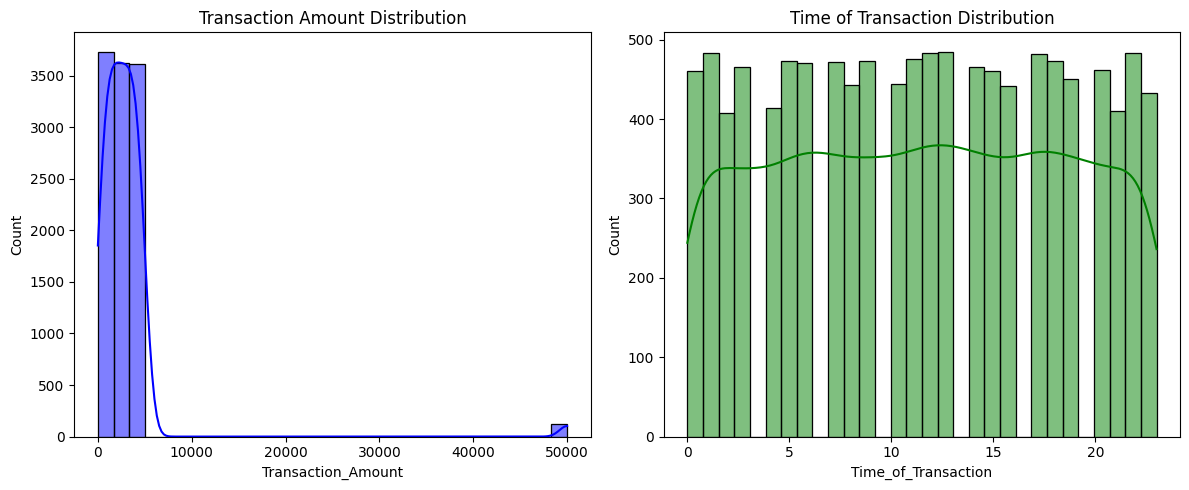

In [14]:
# Visual check of distributions for numerical columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_main["Transaction_Amount"].dropna(), bins=30, kde=True, color="blue", ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')
axes[0].grid(False)
sns.histplot(df_main["Time_of_Transaction"].dropna(), bins=30, kde=True, color="green", ax=axes[1])
axes[1].set_title('Time of Transaction Distribution')
axes[1].grid(False)
plt.tight_layout()
plt.show()

In [15]:
# Impute based on skewness
numerical_columns = ["Transaction_Amount", "Time_of_Transaction"]
for col1 in numerical_columns:
    skewness = df_main[col1].skew()
    print(f"{col1} skewness: {skewness:.2f}")
    if abs(skewness) > 0.5:
        impute_value = df_main[col1].median()
        method = 'median'
    else:
        impute_value = df_main[col1].mean()
        method = 'mean'
    missing_count = df_main[col1].isnull().sum()
    df_main[col1] = df_main[col1].fillna(impute_value)
    print(f"{col1}: Filled {missing_count} missing values with {method} ({impute_value:.2f})")

Transaction_Amount skewness: 8.20
Transaction_Amount: Filled 559 missing values with median (2518.50)
Time_of_Transaction skewness: -0.01
Time_of_Transaction: Filled 632 missing values with mean (11.50)


In [31]:
round(df_main["Device_Used"].value_counts(normalize=True),6)*100

,proportion
Device_Used,
Desktop,31.6246
Mobile,30.9291
Tablet,29.6754
Unknown,4.8429
Unknown Device,2.9280


In [18]:
round(df_main.isnull().sum()/len(df_main.index),4)*100

,0
Transaction_ID,0.0
User_ID,0.0
Transaction_Amount,0.0
Transaction_Type,0.0
Time_of_Transaction,0.0
Device_Used,0.0
Location,0.0
Previous_Fraudulent_Transactions,0.0
Account_Age,0.0
Number_of_Transactions_Last_24H,0.0


In [35]:
# Handle categorical missing values for categorical columns
# Replacing Unknown and Unknown Device with Desktop
categorical_columns = ["Device_Used"]
for col in categorical_columns:
    missing_count = df_main[col].isnull().sum()
    df_main[col] = df_main[col].fillna('Desktop')
    print(f"{col}: Filled {missing_count} missing values with 'Desktop'")
df_main[categorical_columns] = df_main[categorical_columns].replace(['Unknown' , 'Unknown Device'], 'Desktop')

Device_Used: Filled 0 missing values with 'Desktop'


In [36]:
df_main.isnull().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,0
Transaction_Type,0
Time_of_Transaction,0
Device_Used,0
Location,0
Previous_Fraudulent_Transactions,0
Account_Age,0
Number_of_Transactions_Last_24H,0


In [37]:
#checking for Duplicates
df_main[df_main.duplicated()]

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent


In [39]:
df_main.shape

(11646, 12)

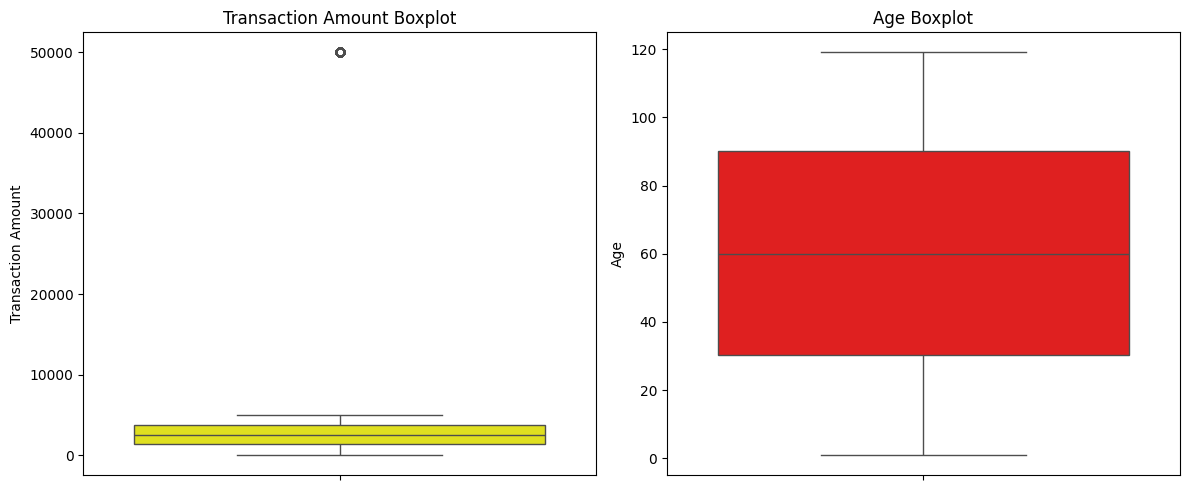

In [40]:
# Combined boxplots for key numerical columns (in subplots) and outlier reporting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df_main["Transaction_Amount"], ax=axes[0], color="yellow")
axes[0].set_title('Transaction Amount Boxplot')
axes[0].set_ylabel("Transaction Amount")
axes[0].grid(False)
sns.boxplot(y=df_main["Account_Age"], ax=axes[1], color="red")
axes[1].set_title('Age Boxplot')
axes[1].set_ylabel('Age')
axes[1].grid(False)
plt.tight_layout()
plt.show()

In [41]:
df_main.head(20)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4507,1554.58,ATM Withdrawal,13.000000,Mobile,New York,4,79,3,Credit Card,0
1,T2,2130,1490.50,POS Payment,19.000000,Mobile,San Francisco,2,57,7,Credit Card,0
2,T3,2095,2372.04,ATM Withdrawal,15.000000,Desktop,Boston,3,96,14,Credit Card,0
3,T4,2238,2733.84,Bill Payment,20.000000,Mobile,San Francisco,2,68,1,Credit Card,0
4,T5,3433,4519.04,Bill Payment,13.000000,Tablet,Boston,0,81,10,Credit Card,1
5,T6,3324,428.39,POS Payment,20.000000,Desktop,New York,0,85,10,Credit Card,0
6,T7,3904,821.79,ATM Withdrawal,7.000000,Mobile,San Francisco,2,116,10,Credit Card,0
7,T8,3047,4413.05,Bank Transfer,21.000000,Desktop,Boston,4,46,11,Credit Card,1
8,T9,1975,4972.42,Online Purchase,13.000000,Tablet,Houston,1,93,14,Credit Card,0
9,T10,2528,2382.83,POS Payment,11.497639,Desktop,New York,0,27,14,Credit Card,0


In [43]:
#Developing synthetic dataset
#Finding fraudscore
#Normalizing dataset
#Normalizing the columns by creating a normalize function
def normalize(columns):
  return (columns - columns.min()) / (columns.max() - columns.min())

df_main["Normalized_Amt"] = normalize(df_main["Transaction_Amount"])

df_main["Normalized_History"] = normalize(df_main["Previous_Fraudulent_Transactions"])

df_main["Normalized_Frequency"] = normalize(df_main["Number_of_Transactions_Last_24H"])

df_main["Normalized_Time"] = normalize(df_main["Time_of_Transaction"])

df_main["Nomalized_Age"] = normalize(df_main["Account_Age"])

#Assign risk weights to
#using the probability of occurence and for example fraud_rate/max_fraud_rate so risk score varies between 0 to 1,calculated the transaction type risk
Transaction_Type_Risk = {
    "Bill Payment":0.25,
    "ATM Withdrawal":0.25,
    "POS Payment":0.25,
    "Bank Transfer":0.5,
    "Online Purchase":1
}
df_main["Normalized_Transaction_Type"] = df_main["Transaction_Type"].map(Transaction_Type_Risk)
device_risk = {
    "Mobile":1,
    "Desktop":0.594,
    "Tablet":0.2
}
df_main["Normalized_Device"]= df_main["Device_Used"].map(device_risk)

Location_risk = {
    "Boston":1,
    "Seattle":0.5,
    "Chicago":0.5,
    "Houston":0.5,
    "New York":0.5,
    "Los Angeles":0.5,
    "Miami":0.5,
    "San Francisco":0.5
}

df_main["Normalized_Location"]= df_main["Location"].map(Location_risk)

df_main.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Normalized_Amt,Normalized_History,Normalized_Frequency,Normalized_Time,Nomalized_Age,Normalized_Transaction_Type,Normalized_Device,Normalized_Location
0,T1,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0,0.030987,1.00,0.153846,0.565217,0.661017,0.25,1.000,0.5
1,T2,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0,0.029705,0.50,0.461538,0.826087,0.474576,0.25,1.000,0.5
2,T3,2095,2372.04,ATM Withdrawal,15.0,Desktop,Boston,3,96,14,Credit Card,0,0.047339,0.75,1.000000,0.652174,0.805085,0.25,0.594,1.0
3,T4,2238,2733.84,Bill Payment,20.0,Mobile,San Francisco,2,68,1,Credit Card,0,0.054576,0.50,0.000000,0.869565,0.567797,0.25,1.000,0.5
4,T5,3433,4519.04,Bill Payment,13.0,Tablet,Boston,0,81,10,Credit Card,1,0.090285,0.00,0.692308,0.565217,0.677966,0.25,0.200,1.0


In [44]:
df_main=df_main.drop(columns=['Transaction_ID','User_ID','Transaction_Amount','Transaction_Type','Time_of_Transaction','Device_Used','Location','Previous_Fraudulent_Transactions',
                    'Account_Age','Number_of_Transactions_Last_24H','Payment_Method'])

In [45]:
df_main.head(20)

,Fraudulent,Normalized_Amt,Normalized_History,Normalized_Frequency,Normalized_Time,Nomalized_Age,Normalized_Transaction_Type,Normalized_Device,Normalized_Location
0,0,0.030987,1.00,0.153846,0.565217,0.661017,0.25,1.000,0.5
1,0,0.029705,0.50,0.461538,0.826087,0.474576,0.25,1.000,0.5
2,0,0.047339,0.75,1.000000,0.652174,0.805085,0.25,0.594,1.0
3,0,0.054576,0.50,0.000000,0.869565,0.567797,0.25,1.000,0.5
4,1,0.090285,0.00,0.692308,0.565217,0.677966,0.25,0.200,1.0
5,0,0.008460,0.00,0.692308,0.869565,0.711864,0.25,0.594,0.5
6,0,0.016329,0.50,0.692308,0.304348,0.974576,0.25,1.000,0.5
7,1,0.088165,1.00,0.769231,0.913043,0.381356,0.50,0.594,1.0
8,0,0.099354,0.25,1.000000,0.565217,0.779661,1.00,0.200,0.5
9,0,0.047554,0.00,1.000000,0.499897,0.220339,0.25,0.594,0.5


In [46]:
df_main=df_main.drop(columns=['Fraudulent'])
df_main.head()

,Normalized_Amt,Normalized_History,Normalized_Frequency,Normalized_Time,Nomalized_Age,Normalized_Transaction_Type,Normalized_Device,Normalized_Location
0,0.030987,1.00,0.153846,0.565217,0.661017,0.25,1.000,0.5
1,0.029705,0.50,0.461538,0.826087,0.474576,0.25,1.000,0.5
2,0.047339,0.75,1.000000,0.652174,0.805085,0.25,0.594,1.0
3,0.054576,0.50,0.000000,0.869565,0.567797,0.25,1.000,0.5
4,0.090285,0.00,0.692308,0.565217,0.677966,0.25,0.200,1.0


In [47]:
weights = [0.69889365, -0.63714044, -0.42977976, -0.79748811,  0.66212057,  0.23496092,  0.14210112,  1.58230292]


In [48]:
df_amount = pd.DataFrame()
df_amount["Normalized_Amt"]=weights[0]*df_main["Normalized_Amt"]

In [49]:
df_main["Fraud_Score"]=weights[0]*df_main["Normalized_Amt"]+weights[1]*df_main["Normalized_History"]+weights[2]*df_main["Normalized_Frequency"]+weights[3]*df_main["Normalized_Time"]+weights[4]*df_main["Nomalized_Age"]+weights[5]*df_main["Normalized_Transaction_Type"]+weights[6]*df_main["Normalized_Device"]+weights[7]*df_main["Normalized_Location"]

In [56]:
df_fraud_min=min(df_main["Fraud_Score"])
df_fraud_max=max(df_main["Fraud_Score"])
print(df_fraud_min)
print(df_fraud_max)
df_main["Fraudulent"]=pd.cut(df_main["Fraud_Score"],bins=[df_fraud_min,0.25*((df_fraud_max+df_fraud_min)/2),0.75*((df_fraud_max+df_fraud_min)/2),df_fraud_max],labels=[0,1,2])
print(df_main["Fraudulent"])

-0.8571528763983869
2.8956711847938896
0        1
1        0
2        2
3        1
4        2
        ..
11641    2
11642    0
11643    0
11644    1
11645    0
Name: Fraudulent, Length: 11646, dtype: category
Categories (3, int64): [0 < 1 < 2]


In [57]:
df_main.head(100)

,Normalized_Amt,Normalized_History,Normalized_Frequency,Normalized_Time,Nomalized_Age,Normalized_Transaction_Type,Normalized_Device,Normalized_Location,Fraud_Score,Fraudulent
0,0.030987,1.00,0.153846,0.565217,0.661017,0.25,1.000,0.5,0.297308,1
1,0.029705,0.50,0.461538,0.826087,0.474576,0.25,1.000,0.5,0.151256,0
2,0.047339,0.75,1.000000,0.652174,0.805085,0.25,0.594,1.0,0.863863,2
3,0.054576,0.50,0.000000,0.869565,0.567797,0.25,1.000,0.5,0.394047,1
4,0.090285,0.00,0.692308,0.565217,0.677966,0.25,0.200,1.0,1.433164,2
...,...,...,...,...,...,...,...,...,...,...
95,0.094207,1.00,0.461538,0.260870,0.508475,0.50,1.000,0.5,0.409705,1
96,0.022951,0.75,0.692308,0.000000,0.610169,1.00,1.000,0.5,0.812864,2
97,0.054371,1.00,0.538462,0.130435,0.330508,0.25,1.000,0.5,0.276248,1
98,0.071099,0.00,0.846154,0.499897,0.559322,0.25,1.000,0.5,0.649700,1
